# 0 Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import seaborn as sns

from src.suporte import funcoes_suporte as fs

from sklearn import preprocessing as pp

## 0.1 Funções Suporte

In [2]:
fs.jupyter_settings(altura = 10, largura = 14, fonte = 8)
fs.supressao_notacao(casa_decimal = 6)

# 0.2 Load Data

In [33]:
df = fs.load_pickle("../data/interim/3.fe.pkl")
df.sample(5)

,customer_id,faturamento,recencia_days,qtde_compras,qtde_produto_comprado,avg_faturamento,avg_recency_days,frequencia,retornos
1684,16332,1593.200000,28,7,134,10.413072,46.166667,0.025180,1.000000
1634,14540,996.260000,9,3,76,13.108684,150.000000,0.009967,0.000000
1813,14944,5900.250000,29,12,299,34.707353,44.500000,0.044776,2.000000
1457,16043,773.990000,37,4,203,19.845897,93.333333,0.014235,0.000000
2583,16092,817.860000,114,3,67,16.036471,70.000000,0.021277,2.000000


In [34]:
df.columns

Index(['customer_id', 'faturamento', 'recencia_days', 'qtde_compras',
       'qtde_produto_comprado', 'avg_faturamento', 'avg_recency_days',
       'frequencia', 'retornos'],
      dtype='object')

# 1.0 Visualização da Distribuição

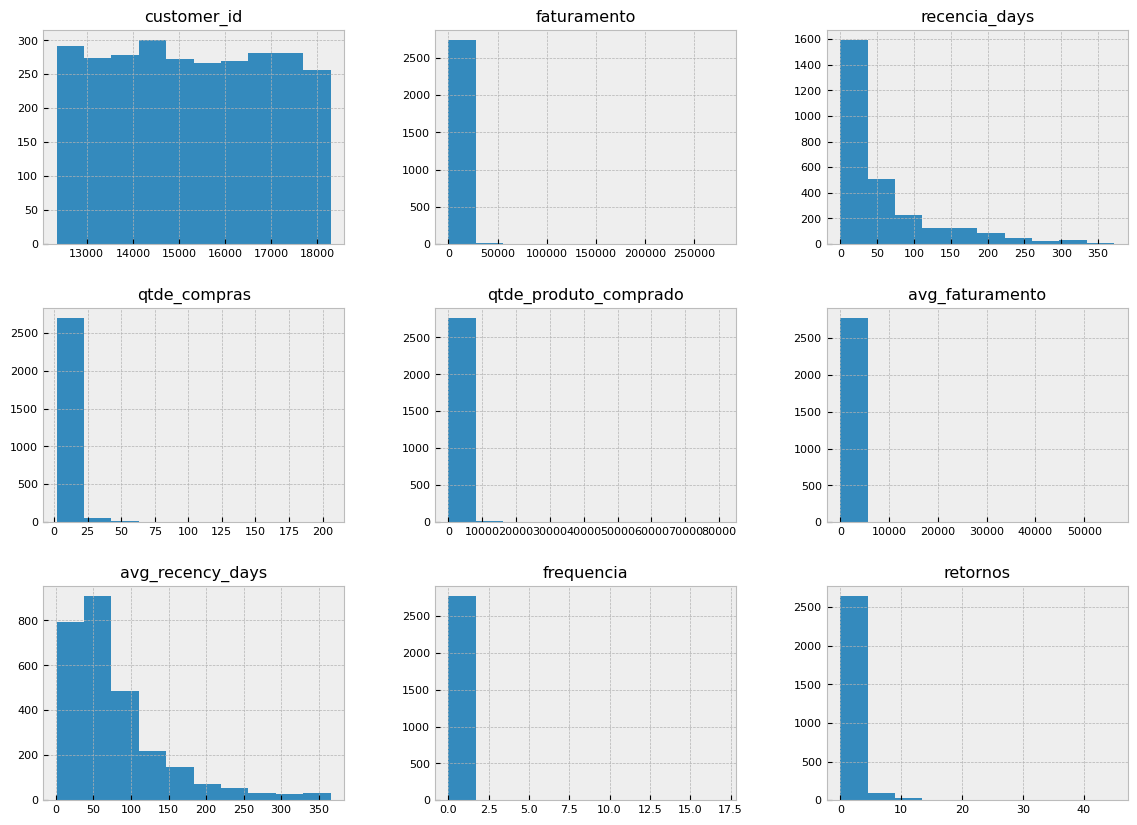

In [35]:
df.hist();

# 2.0 Encoders

# 3.0 Reescala

In [36]:
df.columns

Index(['customer_id', 'faturamento', 'recencia_days', 'qtde_compras',
       'qtde_produto_comprado', 'avg_faturamento', 'avg_recency_days',
       'frequencia', 'retornos'],
      dtype='object')

In [37]:
mms = pp.MinMaxScaler()
ss = pp.StandardScaler()

In [38]:
for col in df.columns:
    if not(col == 'customer_id'):
        df[col] = mms.fit_transform(df[[col]])

In [39]:
for col in df.columns:
    if not(col == 'customer_id'):
        df[col] = np.log1p(df[col])

In [40]:
df.head()

,customer_id,faturamento,recencia_days,qtde_compras,qtde_produto_comprado,avg_faturamento,avg_recency_days,frequencia,retornos
0,17850,0.019004,0.693147,0.145712,0.000420,0.000285,0.000000,0.693147,0.021979
1,13047,0.011386,0.140229,0.033738,0.001604,0.000298,0.132789,0.001344,0.144581
2,12583,0.023613,0.005362,0.061777,0.019162,0.000476,0.067531,0.002050,0.043485
3,13748,0.003261,0.227435,0.014599,0.002072,0.000565,0.224056,0.000734,0.000000
4,15100,0.003003,0.639304,0.004890,0.000580,0.005148,0.050745,0.003977,0.064539


# 5.0 Visualização Distribuição

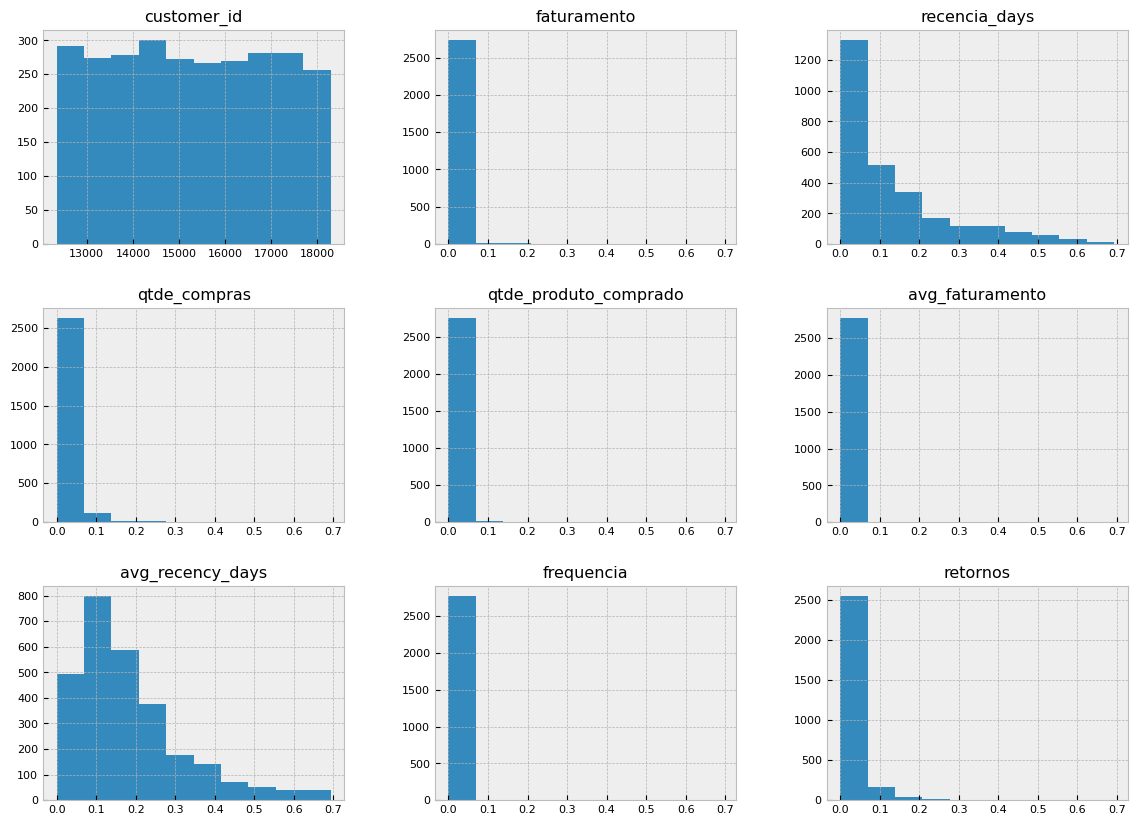

In [41]:
df.hist();

# 4.0 Exportar DF

In [42]:
fs.save_pickle(df,'../data/interim/5.data_prep.pkl')